# End of notebook

print('Notebook cells created. Run this notebook in VS Code or Jupyter to execute each section.')

In [1]:
# Create a small pytest test file
with open('test_sample.py','w') as f:
    f.write('def test_add():\n    assert 1+1==2\n')

print('To run tests manually:')
print('pytest -q test_sample.py')


To run tests manually:
pytest -q test_sample.py


## Section 5 — Testing & Export: programmatic notebook execution and tests

This section shows how to execute a notebook programmatically and how to run a simple pytest test created on the fly.

In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics
import joblib

# Synthetic dataset
X, y = make_classification(n_samples=200, n_features=5, n_informative=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
print('Accuracy:', metrics.accuracy_score(y_test, pred))
print(metrics.classification_report(y_test, pred))

# Persist model
joblib.dump(pipe, 'notebooks_model.joblib')
print('Saved model to notebooks_model.joblib')

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.89      0.94        18

    accuracy                           0.95        40
   macro avg       0.96      0.94      0.95        40
weighted avg       0.95      0.95      0.95        40

Saved model to notebooks_model.joblib


# Examples Notebook
This notebook contains multiple runnable examples: basic Python, data analysis, visualization, a simple scikit-learn pipeline, and programmatic notebook execution/export.

Run cells sequentially. The notebook also demonstrates writing small files and running tests programmatically.

## Section 1 — Basic Python: Hello, Functions, and File I/O

This section demonstrates basic Python usage: printing, functions, exception handling, file read/write, comprehensions, and simple asserts.

## Section 2 — Data Analysis with pandas (CSV -> Cleaning -> Aggregation)

This section uses pandas to load a sample CSV, clean it, create derived columns, and perform groupby aggregation.

In [2]:
# Hello
print('Hello from the examples notebook')

# Functions and exception handling
def safe_div(a, b):
    try:
        return a / b
    except Exception as e:
        return f'Error: {e}'

print('safe_div(4,2)=', safe_div(4,2))
print('safe_div(4,0)=', safe_div(4,0))

# File I/O
with open('notebooks_sample.txt', 'w', encoding='utf-8') as f:
    f.write('sample line\n')

with open('notebooks_sample.txt', 'r', encoding='utf-8') as f:
    print('File content:', f.read())

# Comprehensions
squares = [x*x for x in range(5)]
mapping = {x: x*x for x in range(5)}
print('squares:', squares)
print('mapping:', mapping)

# Simple asserts (quick unit-style checks)
assert safe_div(6,3) == 2
assert squares[3] == 9
print('Basic asserts passed')

Hello from the examples notebook
safe_div(4,2)= 2.0
safe_div(4,0)= Error: division by zero
File content: sample line

squares: [0, 1, 4, 9, 16]
mapping: {0: 0, 1: 1, 2: 4, 3: 9, 4: 16}
Basic asserts passed


## Section 3 — Visualization with matplotlib & seaborn

This section shows simple plots (line, scatter, histogram, boxplot) from the cleaned DataFrame.

In [3]:
import pandas as pd
import numpy as np

# Create a sample CSV
df = pd.DataFrame({
    'student': ['s1','s2','s3','s1','s2'],
    'projection': ['AP','PA','AP','PA','AP'],
    'identifikasi_student':[2,1,3,2,2],
    'identifikasi_assessor':[2,2,3,1,2],
    'kontras_student':[3,2,2,3,1],
    'kontras_assessor':[3,2,1,3,2],
    'score':[80,70,90,60,75]
})

csv_path = 'notebooks_sample.csv'
df.to_csv(csv_path, index=False)
print('Wrote sample CSV to', csv_path)

# Load and inspect
df2 = pd.read_csv(csv_path)
print(df2.head())
print(df2.info())

# Handle missing values (none here) and convert dtypes
# Example derived column: diff_identifikasi
for col in ['identifikasi','kontras']:
    df2[f'diff_{col}'] = df2[f'{col}_assessor'] - df2[f'{col}_student']

# Groupby aggregation
agg = df2.groupby('projection').agg(mean_score=('score','mean'), count=('score','count'))
print('\nAggregation by projection:\n', agg)

# Save cleaned CSV
clean_path = 'notebooks_sample_clean.csv'
df2.to_csv(clean_path, index=False)
print('Saved cleaned CSV to', clean_path)

Wrote sample CSV to notebooks_sample.csv
  student projection  identifikasi_student  identifikasi_assessor  \
0      s1         AP                     2                      2   
1      s2         PA                     1                      2   
2      s3         AP                     3                      3   
3      s1         PA                     2                      1   
4      s2         AP                     2                      2   

   kontras_student  kontras_assessor  score  
0                3                 3     80  
1                2                 2     70  
2                2                 1     90  
3                3                 3     60  
4                1                 2     75  
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   student                5 non-null      str  
 1   projection             5

## Section 4 — Machine Learning: scikit-learn classification pipeline

Simple classification pipeline with synthetic data, pipeline, evaluation, and model persistence.

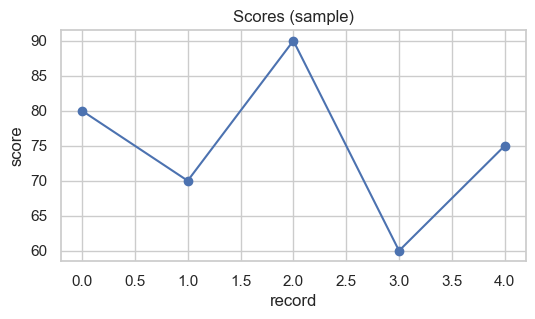

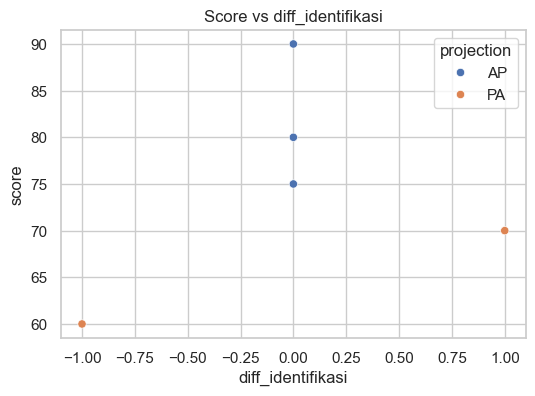

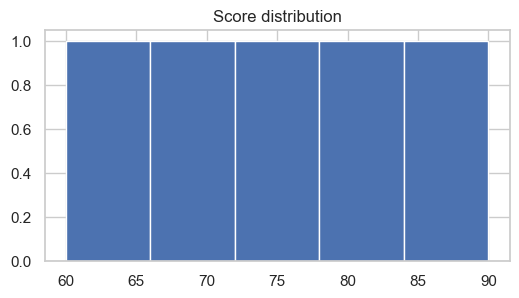

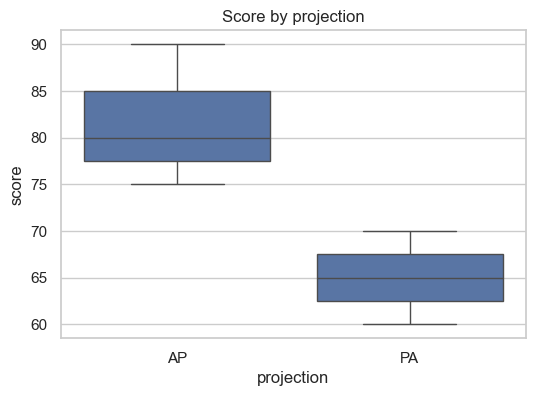

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Load cleaned data
dfv = pd.read_csv('notebooks_sample_clean.csv')

# Line plot: scores per row
plt.figure(figsize=(6,3))
plt.plot(dfv['score'], marker='o')
plt.title('Scores (sample)')
plt.xlabel('record')
plt.ylabel('score')
plt.savefig('notebooks_scores_line.png')
plt.show()

# Scatter: identifikasi diff vs score
plt.figure(figsize=(6,4))
sns.scatterplot(data=dfv, x='diff_identifikasi', y='score', hue='projection')
plt.title('Score vs diff_identifikasi')
plt.savefig('notebooks_scatter.png')
plt.show()

# Histogram
plt.figure(figsize=(6,3))
plt.hist(dfv['score'], bins=5)
plt.title('Score distribution')
plt.savefig('notebooks_hist.png')
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='projection', y='score', data=dfv)
plt.title('Score by projection')
plt.savefig('notebooks_box.png')
plt.show()